# Sisson 1987 Analytical Drainage Validation Check

This notebook is a small, separate validation notebook for checking the analytical drainage solution used in the forward model workflow.

The goal is **not** to exactly reproduce the field-data scatterplots in Sisson (1987). Those figures use measured Tipton field soil data. Instead, this notebook checks whether the synthetic analytical solution follows the same mathematical behavior described by Sisson's fixed-gradient solution.

Main checks:

1. Generate water-content profiles through time using the Sisson/Brooks-Corey analytical solution.
2. Make a Sisson-style transformed plot using `z_star / t` versus water content.
3. Confirm numerically that, in the unclipped drainage region, `z_star / t = dK/dtheta`.

If the implementation is correct, points from different drainage times should collapse onto a single curve in the transformed plot, and the numerical error in the identity check should be very small.


## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")


## 2. Define One Test Soil

This uses one simple Brooks-Corey/Sisson soil case. The exact values do not need to match Sisson's field site because this is a mathematical validation of the solution form.

For this saturated-initial-condition check, `q0 = Ks` is used so that `z_star = z`. That makes the first validation as simple as possible.

Important: `bc_n` here is the Sisson/Brooks-Corey exponent in `K = Ks * Se**(1 / bc_n)`. It should be the fitted or converted Sisson exponent used by your analytical model, **not** the raw van Genuchten `n`.


In [2]:
# Soil hydraulic parameters
# Units: theta is dimensionless, Ks and q0 are cm/hr, z is cm, t is hr.
soil = {
    "name": "loamy_sand_test",
    "theta_r": 0.057,
    "theta_s": 0.410,
    "Ks": 14.6,
    # This is a Sisson/Brooks-Corey exponent, not raw van Genuchten n.
    # A value less than 1 gives the expected drainage behavior for this exponent convention.
    "bc_n": 0.56,
}

# For the simplest saturated initial condition benchmark, set q0 equal to Ks.
soil["q0"] = soil["Ks"]

# Positive downward depth grid and drainage times.
z = np.linspace(1, 600, 300)  # cm
times = np.array([1, 4, 12, 24, 48], dtype=float)  # hr

soil


{'name': 'loamy_sand_test',
 'theta_r': 0.057,
 'theta_s': 0.41,
 'Ks': 14.6,
 'bc_n': 0.56,
 'q0': 14.6}

## 3. Analytical Sisson/Brooks-Corey Solution

The Brooks-Corey conductivity model used here is:

$$
K(\theta) = K_s S_e^{1/n}
$$

where:

$$
S_e = \frac{\theta - \theta_r}{\theta_s - \theta_r}
$$

For the Sisson analytical solution, the middle drainage region satisfies:

$$
\frac{z^*}{t} = \frac{dK}{d\theta}
$$

and the solution is clipped to the physically meaningful range between `theta_r` and `theta_s`.


In [3]:
def theta_brooks_corey_sisson_piecewise(
    z,
    t,
    theta_r,
    theta_s,
    Ks,
    bc_n,
    q0,
    return_diagnostics=False,
):
    """Sisson/Brooks-Corey piecewise drainage solution."""
    z = np.asarray(z, dtype=float)

    if t <= 0:
        theta = np.full_like(z, theta_s)
        if return_diagnostics:
            return {
                "theta": theta,
                "theta_mid": theta,
                "z_star": np.full_like(z, np.nan),
                "s_star": np.full_like(z, np.nan),
                "unclipped": np.zeros_like(z, dtype=bool),
            }
        return theta

    # Sisson transformed depth for the Brooks-Corey form.
    z_star = (Ks / q0) ** bc_n * z
    s_star = np.maximum(z_star / t, 1e-30)

    # dK/dtheta = A * Se**((1 / bc_n) - 1)
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    theta_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent
    theta = np.clip(theta_mid, theta_r, theta_s)
    unclipped = (theta_mid > theta_r) & (theta_mid < theta_s)

    if return_diagnostics:
        return {
            "theta": theta,
            "theta_mid": theta_mid,
            "z_star": z_star,
            "s_star": s_star,
            "unclipped": unclipped,
            "A": A,
            "exponent": exponent,
        }

    return theta


def effective_saturation(theta, theta_r, theta_s):
    """Effective saturation clipped to avoid exactly zero values."""
    Se = (np.asarray(theta) - theta_r) / (theta_s - theta_r)
    return np.clip(Se, 1e-30, 1.0)


def dK_dtheta_brooks_corey(theta, theta_r, theta_s, Ks, bc_n):
    """Derivative dK/dtheta for K = Ks * Se**(1 / bc_n)."""
    Se = effective_saturation(theta, theta_r, theta_s)
    return Ks / (bc_n * (theta_s - theta_r)) * Se ** ((1 / bc_n) - 1)


## 4. Generate Profiles


In [4]:
profiles = {}
diagnostics = {}

for t in times:
    out = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=soil["theta_r"],
        theta_s=soil["theta_s"],
        Ks=soil["Ks"],
        bc_n=soil["bc_n"],
        q0=soil["q0"],
        return_diagnostics=True,
    )
    profiles[t] = out["theta"]
    diagnostics[t] = out

profile_df = pd.DataFrame({f"{t:g} hr": profiles[t] for t in times})
profile_df.insert(0, "z_cm", z)
profile_df.head()


,z_cm,1 hr,4 hr,12 hr,24 hr,48 hr
0,1.000000,0.058479,0.057253,0.057063,0.057026,0.057011
1,3.003344,0.062994,0.058027,0.057254,0.057105,0.057043
2,5.006689,0.068486,0.058967,0.057486,0.057201,0.057083
3,7.010033,0.074628,0.060020,0.057746,0.057309,0.057128
4,9.013378,0.081274,0.061158,0.058027,0.057425,0.057176


## 5. Check 1: Water-Content Profiles

This is the familiar plot from the main workflow. It should show a drainage profile that evolves with time while staying between `theta_r` and `theta_s`.


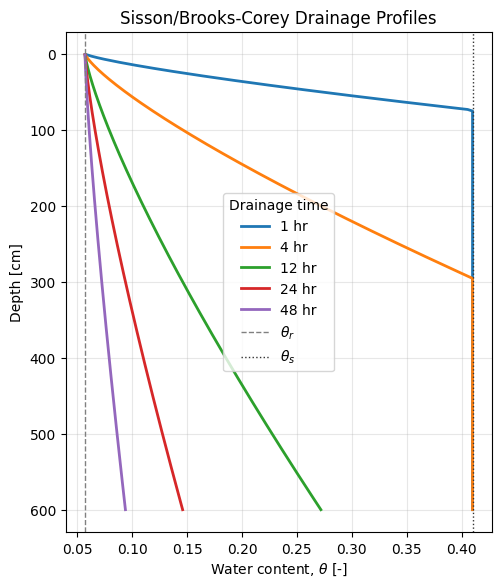

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 6.5))

for t in times:
    ax.plot(profiles[t], z, linewidth=2, label=f"{t:g} hr")

ax.axvline(soil["theta_r"], color="0.5", linestyle="--", linewidth=1, label=r"$\theta_r$")
ax.axvline(soil["theta_s"], color="0.2", linestyle=":", linewidth=1, label=r"$\theta_s$")
ax.invert_yaxis()
ax.set_xlabel(r"Water content, $\theta$ [-]")
ax.set_ylabel("Depth [cm]")
ax.set_title("Sisson/Brooks-Corey Drainage Profiles")
ax.legend(title="Drainage time")
ax.grid(True, alpha=0.3)
plt.show()


## 6. Check 2: Sisson-Style Transformed Collapse Plot

Sisson's key visual idea is that transformed drainage data should collapse onto a single relationship.

Here we plot:

$$
\frac{z^*}{t}
$$

against water content for all drainage times. Because these are synthetic data from the analytical equation, the points from different times should lie on the same curve in the unclipped middle region.


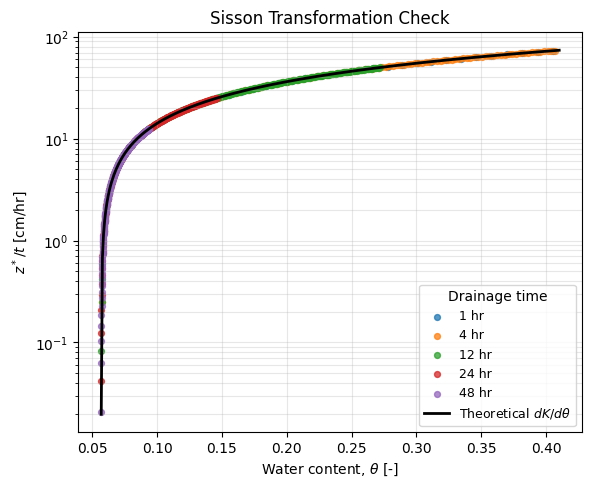

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))

for t in times:
    theta = diagnostics[t]["theta"]
    s_star = diagnostics[t]["s_star"]
    unclipped = diagnostics[t]["unclipped"]

    # Plot only the middle analytical drainage region for the cleanest validation.
    ax.scatter(
        theta[unclipped],
        s_star[unclipped],
        s=18,
        alpha=0.75,
        label=f"{t:g} hr",
    )

# Add the theoretical dK/dtheta curve for reference.
theta_curve = np.linspace(soil["theta_r"] + 1e-5, soil["theta_s"] - 1e-5, 400)
dK_curve = dK_dtheta_brooks_corey(
    theta_curve,
    theta_r=soil["theta_r"],
    theta_s=soil["theta_s"],
    Ks=soil["Ks"],
    bc_n=soil["bc_n"],
)
ax.plot(theta_curve, dK_curve, color="black", linewidth=2, label=r"Theoretical $dK/d\theta$")

ax.set_yscale("log")
ax.set_xlabel(r"Water content, $\theta$ [-]")
ax.set_ylabel(r"$z^*/t$ [cm/hr]")
ax.set_title("Sisson Transformation Check")
ax.legend(title="Drainage time", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.show()


## 7. Check 3: Numerical Identity Check

For all points in the middle drainage region, the analytical solution should satisfy:

$$
\frac{z^*}{t} = \frac{dK}{d\theta}
$$

This cell calculates the absolute and relative error for each drainage time.


In [7]:
check_rows = []

for t in times:
    theta = diagnostics[t]["theta"]
    s_star = diagnostics[t]["s_star"]
    unclipped = diagnostics[t]["unclipped"]

    dK = dK_dtheta_brooks_corey(
        theta,
        theta_r=soil["theta_r"],
        theta_s=soil["theta_s"],
        Ks=soil["Ks"],
        bc_n=soil["bc_n"],
    )

    abs_error = np.abs(s_star[unclipped] - dK[unclipped])
    rel_error = abs_error / np.maximum(np.abs(dK[unclipped]), 1e-30)

    check_rows.append({
        "time_hr": t,
        "n_unclipped_points": int(unclipped.sum()),
        "max_abs_error": abs_error.max() if abs_error.size else np.nan,
        "mean_abs_error": abs_error.mean() if abs_error.size else np.nan,
        "max_relative_error": rel_error.max() if rel_error.size else np.nan,
        "mean_relative_error": rel_error.mean() if rel_error.size else np.nan,
    })

identity_check = pd.DataFrame(check_rows)
identity_check


,time_hr,n_unclipped_points,max_abs_error,mean_abs_error,max_relative_error,mean_relative_error
0,1.0,37,1.421085e-14,3.294662e-15,8.871894e-16,1.234044e-16
1,4.0,147,1.421085e-14,2.089787e-15,1.330784e-15,1.065449e-16
2,12.0,300,1.421085e-14,1.722002e-15,3.459268e-15,1.378754e-16
3,24.0,300,7.105427e-15,1.513118e-15,1.010858e-13,6.809181e-16
4,48.0,300,3.552714e-15,1.172847e-15,1.676992e-13,1.178058e-15


## 8. Interpretation

Use this notebook as a focused validation check before making changes to the full forward model.

A successful result should look like this:

- The water-content profiles stay between `theta_r` and `theta_s`.
- The transformed points from different times collapse onto one curve.
- The theoretical `dK/dtheta` curve overlays the transformed points.
- The numerical identity errors are close to machine precision for the unclipped middle region.

If those conditions hold, the analytical Sisson/Brooks-Corey implementation is behaving correctly. Then any strange behavior later in the full workflow is more likely to come from parameter choices, units, Archie conversion, TEM setup, or clustering choices rather than from the analytical drainage equation itself.
